In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import yfinance as yf
import pandas_datareader.data as web
import datetime
import requests
import seaborn as sns

In [109]:
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
merged_data = pd.read_csv('merged_data.csv')

In [7]:
merged_data.head()

,Unnamed: 0,date,underlying_price,implied_volatility,risk_free_rate
0,0,2024-04-30,501.98,0.1565,5.25
1,1,2024-05-01,500.35,0.1539,5.26
2,2,2024-05-02,505.03,0.1468,5.25
3,3,2024-05-03,511.29,0.1349,5.25
4,4,2024-05-06,516.57,0.1349,5.25


In [9]:
merged_data.describe()

,Unnamed: 0,underlying_price,implied_volatility,risk_free_rate
count,253.000000,253.000000,253.000000,253.000000
mean,126.000000,565.170474,0.181579,4.630158
std,73.179004,28.127478,0.060426,0.430384
min,0.000000,496.480000,0.118600,4.170000
25%,63.000000,544.510000,0.142800,4.220000
50%,126.000000,563.980000,0.164300,4.480000
75%,189.000000,590.300000,0.199000,5.140000
max,252.000000,612.930000,0.523300,5.260000


In [13]:
merged_data['date'] = pd.to_datetime(merged_data['date'])

In [15]:
merged_data['rate'] = merged_data['risk_free_rate'] / 100

In [17]:
merged_data.head()

,Unnamed: 0,date,underlying_price,implied_volatility,risk_free_rate,rate
0,0,2024-04-30,501.98,0.1565,5.25,0.0525
1,1,2024-05-01,500.35,0.1539,5.26,0.0526
2,2,2024-05-02,505.03,0.1468,5.25,0.0525
3,3,2024-05-03,511.29,0.1349,5.25,0.0525
4,4,2024-05-06,516.57,0.1349,5.25,0.0525


In [111]:
CURVATURE = 0.20    
SKEW      = -0.25   
SKEW_DECAY   = 1.0     
NOISE_STD = 0.005 
OPTION_TYPE = 'call'

In [47]:
# MONEYNESS = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20])
# MATURITIES = np.array([21/252, 42/252, 63/252, 126/252, 189/252, 252/252])
 
# np.random.seed(42)

In [113]:
def synthetic_iv(base_iv, E, S, T,
                 curvature=CURVATURE, skew=SKEW,
                 skew_decay=SKEW_DECAY, noise_std=NOISE_STD):

    x              = np.log(E / S)
    curvature_term = curvature * x**2
    skew_term      = skew * x * np.exp(-skew_decay * T)
    noise          = np.random.normal(0, noise_std)
    iv             = base_iv + curvature_term + skew_term + noise
    iv = float(np.clip(iv, 0.03, 1.50))
    return iv 

In [157]:
def synthetic_iv(base_iv, E, S, T, r,
                 curvature0=0.15,
                 curvature1=0.08,
                 curvature_decay=1.0,
                 skew0=-0.22,
                 skew_decay=1.2,
                 atm_term_alpha=0.03,
                 atm_term_decay=1.0,
                 noise_std=0.003,
                 wing_noise_scale=0.75,
                 sigma_floor=0.03,
                 sigma_cap=1.50,
                 rng=None):

    if rng is None:
        rng = np.random.default_rng()

    T = max(T, 1e-10)

   
    F = S * np.exp(r * T)
    x = np.log(E / F)

     
    atm_T = base_iv * (1.0 + atm_term_alpha * np.exp(-atm_term_decay * T))

     
    curvature_T = curvature0 + curvature1 * np.exp(-curvature_decay * T)
    skew_T = skew0 * np.exp(-skew_decay * T)

    
    noise_std_eff = noise_std * (1.0 + wing_noise_scale * abs(x))
    noise = rng.normal(0.0, noise_std_eff)

    iv = atm_T + curvature_T * x**2 + skew_T * x + noise
    iv = float(np.clip(iv, sigma_floor, sigma_cap))
    return iv

In [159]:
def bs_price(S, E, T, r, sigma, option_type=OPTION_TYPE):
    if T < 1e-6 or sigma < 1e-6:
        return max(S - E, 0) if option_type == 'call' else max(E - S, 0)
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*norm.cdf(d1) - E*np.exp(-r*T)*norm.cdf(d2)
    return E*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_delta(S, E, T, r, sigma, option_type = OPTION_TYPE):
    if T < 1e-6 or sigma < 1e-6:
        return 1.0 if (option_type == 'call' and S > E) else 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1

def bs_vega(S, E, T, r, sigma):
    if T < 1e-6 or sigma < 1e-6: return 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_gamma(S, E, T, r, sigma):
    if T < 1e-6 or sigma < 1e-6: return 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

In [161]:
def create_synthetic_option_panel(
    merged_data,
    moneyness_grid=np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]),
    maturities=np.array([21/252, 42/252, 63/252, 126/252, 189/252, 252/252]),
    issue_every_n_days=5,
    min_days_to_expiry=14, # get rid of data of last 14 days
    seed=42
):
    
    df = merged_data.copy()
    df = df.sort_values("date").reset_index(drop=True)
    df["date"] = pd.to_datetime(df["date"])

    rng = np.random.default_rng(seed)
    records = []

    for issue_idx in range(0, len(df), issue_every_n_days):
        issue_row = df.iloc[issue_idx]
        issue_date = issue_row["date"]
        S_issue = float(issue_row["underlying_price"])

        strikes = S_issue * moneyness_grid

        for T0 in maturities:
            max_days_expiry = int(round(T0 * 252))

            for E in strikes:
                option_id = f"{issue_date.date()}|E={E:.4f}|T0={int(round(T0*252))}"

                for j in range(max_days_expiry + 1):
                    time_elapse_idx = issue_idx + j
                    if time_elapse_idx >= len(df):
                        break

                    tau = T0 - j / 252.0
                    if tau < min_days_to_expiry / 252.0:
                        break

                    row = df.iloc[time_elapse_idx]
                    date = row["date"]
                    S = float(row["underlying_price"])
                    base_iv = float(row["implied_volatility"])
                    r = float(row["rate"])

                   

                    sigma = synthetic_iv(
                        base_iv=base_iv,
                        E=E,
                        S=S,
                        T=tau,
                        r=r,
                        rng=rng
                        )

                    price = bs_price(S, E, tau, r, sigma)
                    delta = bs_delta(S, E, tau, r, sigma)
                    vega = bs_vega(S, E, tau, r, sigma)
                    gamma = bs_gamma(S, E, tau, r, sigma)

                    records.append({
                        "option_id": option_id,
                        "issue_date": issue_date,
                        "date": date,
                        "issue_idx": issue_idx,
                        "time_elapse_idx": time_elapse_idx,
                        "days_since_issue": j,
                        "strike": E,
                        "initial_T": T0,
                        "tau": tau,
                        "underlying_price": S,
                        "rate": r,
                        "implied_vol": sigma,
                        "option_price": price,
                        "delta_bs": delta,
                        "vega_bs": vega,
                        "gamma_bs": gamma
                    })

    panel = pd.DataFrame(records)
    panel = panel.sort_values(["option_id", "date"]).reset_index(drop=True)
    return panel

In [163]:
panel = create_synthetic_option_panel(
    merged_data,
    issue_every_n_days=5
)



In [ ]:
# store dataset in long panel format, one row per contract-date observation

In [164]:
print(panel.shape)
panel.head()

(189009, 16)


,option_id,issue_date,date,issue_idx,time_elapse_idx,days_since_issue,strike,initial_T,tau,underlying_price,rate,implied_vol,option_price,delta_bs,vega_bs,gamma_bs
0,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-04-30,0,0,0,401.584,0.5,0.500000,501.98,0.0525,0.204991,111.915333,0.963515,28.377371,0.001099
1,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-01,0,1,1,401.584,0.5,0.496032,500.35,0.0526,0.198617,110.086748,0.966255,26.424310,0.001071
2,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-02,0,2,2,401.584,0.5,0.492063,505.03,0.0525,0.194406,114.410043,0.973709,21.596275,0.000885
3,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-03,0,3,3,401.584,0.5,0.488095,511.29,0.0525,0.184471,120.267057,0.983712,14.518030,0.000617
4,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-06,0,4,4,401.584,0.5,0.484127,516.57,0.0525,0.186088,125.399838,0.986298,12.590771,0.000524


In [169]:
def add_contract_diff(panel):
    df = panel.copy()
    df = df.sort_values(["option_id", "date"]).reset_index(drop=True)

    df["dV"] = df.groupby("option_id")["option_price"].diff()
    df["dS"] = df.groupby("option_id")["underlying_price"].diff()
    # df["delta_iv"] = df.groupby("option_id")["implied_vol"].diff()

   
    df["delta_bs_lag"] = df.groupby("option_id")["delta_bs"].shift(1)
    df["vega_bs_lag"] = df.groupby("option_id")["vega_bs"].shift(1)
    df["tau_lag"] = df.groupby("option_id")["tau"].shift(1)
    df["S_lag"] = df.groupby("option_id")["underlying_price"].shift(1)

    return df

In [171]:
panel = add_contract_diff(panel)

In [173]:
def estimate_rolling_quadratic_coeffs(
    panel,
    window_size=63,          # e.g. 63 trading days
    step_size=5,
    min_obs=500,
    min_abs_return=0.0015    # filter tiny spot moves
):
   
    df = panel.copy()
    df = df.sort_values(["date", "option_id"]).reset_index(drop=True)

    unique_dates = np.array(sorted(df["date"].dropna().unique()))
    results = []

    for start in range(0, len(unique_dates) - window_size + 1, step_size):
        train_dates = unique_dates[start:start + window_size]
        test_date = unique_dates[start + window_size - 1]

        w = df[df["date"].isin(train_dates)].copy()

       
        w = w.dropna(subset=["dV", "dS", "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag"])

        
        w = w[w["tau_lag"] > 14/252]
        w = w[w["vega_bs_lag"] > 1e-8]
        w = w[w["S_lag"] > 0]

         
        w = w[(w["dS"].abs() / w["S_lag"]) > min_abs_return]

        if len(w) < min_obs:
            results.append({
                "window_end": test_date,
                "a": np.nan,
                "b": np.nan,
                "c": np.nan,
                "n_obs": len(w),
                "r2": np.nan
            })
            continue

        y = (
            (w["dV"] - w["delta_bs_lag"] * w["dS"])
            * w["S_lag"] * np.sqrt(w["tau_lag"])
            / (w["vega_bs_lag"] * w["dS"])
        )

       
        X = pd.DataFrame({
            "const": 1.0,
            "delta": w["delta_bs_lag"],
            "delta_sq": w["delta_bs_lag"] ** 2
        })

       
        y_low, y_high = y.quantile([0.01, 0.99])
        mask = (y >= y_low) & (y <= y_high)
        y_reg = y[mask]
        X_reg = X.loc[mask]

        if len(y_reg) < min_obs:
            results.append({
                "window_end": test_date,
                "a": np.nan,
                "b": np.nan,
                "c": np.nan,
                "n_obs": len(y_reg),
                "r2": np.nan
            })
            continue

        model = sm.OLS(y_reg, X_reg).fit()

        results.append({
            "window_end": test_date,
            "a": model.params["const"],
            "b": model.params["delta"],
            "c": model.params["delta_sq"],
            "n_obs": len(y_reg),
            "r2": model.rsquared
        })

    coeffs = pd.DataFrame(results)
    return coeffs

In [ ]:
# polyfit and sm.OLS
# polyfit: fitted quadratic quickly, convenient for one-variable polynomial fit
#          no regression statistics summary
# sm.OLS: better for an econometric regression framework, 
#         give statistics values, easy to use robust standard errors, more informative

In [175]:
coeffs = estimate_rolling_quadratic_coeffs(
    panel,
    window_size=63,
    step_size=5,
    min_obs=500
)

coeffs.head()

,window_end,a,b,c,n_obs,r2
0,2024-07-30,-1.480604,13.155650,-16.855581,13857,0.015682
1,2024-08-06,-1.030309,4.426862,-6.825917,16160,0.011213
2,2024-08-13,-0.839155,1.370303,-3.089983,18143,0.009172
3,2024-08-20,-0.864436,0.133994,-1.628059,20525,0.008458
4,2024-08-27,-0.760444,-0.515012,-0.692199,22117,0.007001


In [195]:
def merge_coefficients_to_panel(panel, coeffs):
    df = panel.copy().sort_values("date").reset_index(drop=True)
    c = coeffs.copy().sort_values("window_end").reset_index(drop=True)

    df = pd.merge_asof(
        df.sort_values("date"),
        c.rename(columns={"window_end": "date"}).sort_values("date"),
        on="date",
        direction="backward",
        allow_exact_matches=False
    )

    return df

In [197]:
panel_with_coeffs = merge_coefficients_to_panel(panel, coeffs)

In [199]:
def compute_hedging_metrics(panel_with_coeffs):
    df = panel_with_coeffs.copy()

   
    df = df.dropna(subset=[
        "dV", "dS",
        "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag",
        "a", "b", "c"
    ]).copy()

    df["delta_mv_lag"] = (
        df["delta_bs_lag"]
        + (df["vega_bs_lag"] / (df["S_lag"] * np.sqrt(df["tau_lag"])))
        * (df["a"] + df["b"] * df["delta_bs_lag"] + df["c"] * df["delta_bs_lag"]**2)
    )

   
    df["hedge_err_bs"] = df["dV"] - df["delta_bs_lag"] * df["dS"]
    df["hedge_err_mv"] = df["dV"] - df["delta_mv_lag"] * df["dS"]

    df["sq_err_bs"] = df["hedge_err_bs"] ** 2
    df["sq_err_mv"] = df["hedge_err_mv"] ** 2

    
    return df

In [201]:
eval_df = compute_hedging_metrics(panel_with_coeffs)

In [203]:
def overall_gain(eval_df):
    sse_bs = eval_df["sq_err_bs"].sum()
    sse_mv = eval_df["sq_err_mv"].sum()
    gain_pct = 100.0 * (1.0 - sse_mv / sse_bs)
    return {
        "sse_bs": sse_bs,
        "sse_mv": sse_mv,
        "gain_pct": gain_pct
    }

overall = overall_gain(eval_df)
print(overall)

{'sse_bs': 2081557.0621598028, 'sse_mv': 1011481.5438121214, 'gain_pct': 51.40745539963155}


In [205]:
burn_in_windows = 3  
eval_df_clean = eval_df[eval_df['date'] > coeffs.iloc[burn_in_windows]['window_end']]
overall_gain_clean = overall_gain(eval_df_clean)

In [207]:
print(overall_gain_clean)

{'sse_bs': 1742559.0575330092, 'sse_mv': 640638.3390435601, 'gain_pct': 63.23577463420206}


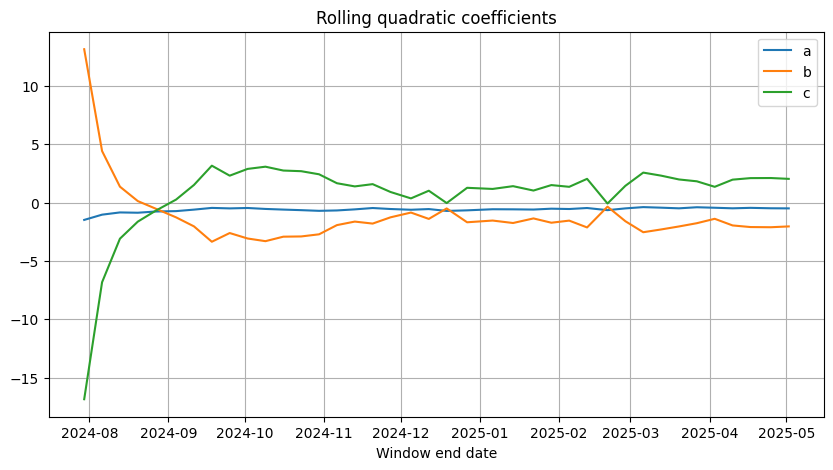

In [209]:
def plot_coefficients(coeffs):
    plt.figure(figsize=(10, 5))
    plt.plot(coeffs["window_end"], coeffs["a"], label="a")
    plt.plot(coeffs["window_end"], coeffs["b"], label="b")
    plt.plot(coeffs["window_end"], coeffs["c"], label="c")
    plt.legend()
    plt.title("Rolling quadratic coefficients")
    plt.xlabel("Window end date")
    plt.grid(True)
    plt.show()

plot_coefficients(coeffs)

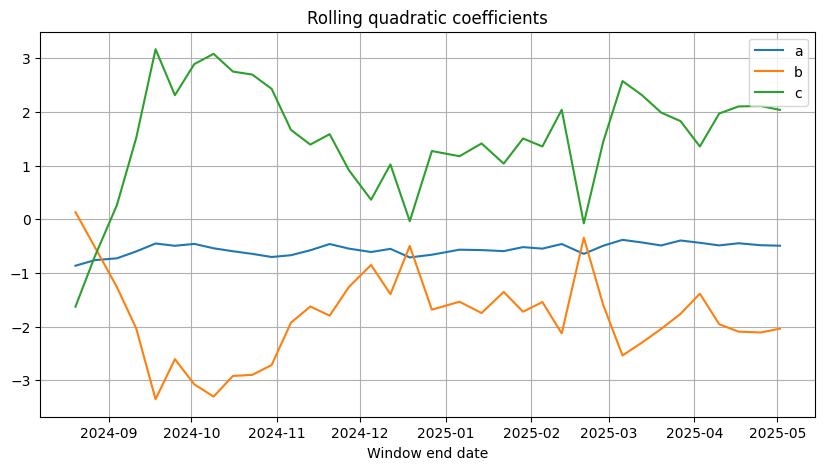

In [211]:
burn_in_windows = 3   
coeffs_report = coeffs.iloc[burn_in_windows:].copy()
plot_coefficients(coeffs_report)

In [213]:
def assign_current_delta_buckets(panel):
    df = panel.copy()

   
    bins = np.arange(0.05, 1.00, 0.10)
   
    edges = np.append(bins, 1.05)

    labels = [f"[{edges[i]:.2f},{edges[i+1]:.2f})" for i in range(len(edges)-1)]

    df["delta_bucket"] = pd.cut(
        df["delta_bs"],
        bins=edges,
        labels=labels,
        right=False,
        include_lowest=True
    )

    return df

In [215]:
def report_gain_by_delta_bucket(eval_df):
    df = eval_df.copy()

   
    if "delta_bucket" not in df.columns:
        df = assign_current_delta_buckets(df)

    summary = (
        df.dropna(subset=["delta_bucket"])
          .groupby("delta_bucket", observed=False)
          .agg(
              n_obs=("sq_err_bs", "size"),
              sse_bs=("sq_err_bs", "sum"),
              sse_mv=("sq_err_mv", "sum"),
              mean_delta=("delta_bs", "mean"),
              mean_tau=("tau", "mean")
          )
          .reset_index()
    )

    summary["gain_pct"] = 100.0 * (1.0 - summary["sse_mv"] / summary["sse_bs"])
    return summary

In [217]:
bucket_report = report_gain_by_delta_bucket(eval_df)
print(bucket_report)

  delta_bucket  n_obs         sse_bs         sse_mv  mean_delta  mean_tau  \
0  [0.05,0.15)  10592   28141.748382   10276.007720    0.101203  0.299163   
1  [0.15,0.25)  12747  128570.464951   51352.466617    0.201173  0.444653   
2  [0.25,0.35)  13212  295620.053927  135831.630288    0.299717  0.503945   
3  [0.35,0.45)  12395  390759.483682  207091.089388    0.399349  0.510875   
4  [0.45,0.55)  12042  393638.403793  205414.135653    0.499990  0.508264   
5  [0.55,0.65)  12644  363150.350021  168357.729282    0.601151  0.499418   
6  [0.65,0.75)  13735  279621.290520  121349.598292    0.700982  0.501493   
7  [0.75,0.85)  16791  156463.638473   71351.769083    0.802083  0.496930   
8  [0.85,0.95)  25328   41542.368876   33701.767551    0.904783  0.472503   
9  [0.95,1.05)  28705    2739.971562    6271.085392    0.981748  0.281418   

     gain_pct  
0   63.484828  
1   60.058893  
2   54.051957  
3   47.002927  
4   47.816541  
5   53.639662  
6   56.602161  
7   54.397220  
8   18.8

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import yfinance as yf
import pandas_datareader.data as web
import datetime
import requests
import seaborn as sns

In [109]:
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
merged_data = pd.read_csv('merged_data.csv')

In [7]:
merged_data.head()

,Unnamed: 0,date,underlying_price,implied_volatility,risk_free_rate
0,0,2024-04-30,501.98,0.1565,5.25
1,1,2024-05-01,500.35,0.1539,5.26
2,2,2024-05-02,505.03,0.1468,5.25
3,3,2024-05-03,511.29,0.1349,5.25
4,4,2024-05-06,516.57,0.1349,5.25


In [9]:
merged_data.describe()

,Unnamed: 0,underlying_price,implied_volatility,risk_free_rate
count,253.000000,253.000000,253.000000,253.000000
mean,126.000000,565.170474,0.181579,4.630158
std,73.179004,28.127478,0.060426,0.430384
min,0.000000,496.480000,0.118600,4.170000
25%,63.000000,544.510000,0.142800,4.220000
50%,126.000000,563.980000,0.164300,4.480000
75%,189.000000,590.300000,0.199000,5.140000
max,252.000000,612.930000,0.523300,5.260000


In [13]:
merged_data['date'] = pd.to_datetime(merged_data['date'])

In [15]:
merged_data['rate'] = merged_data['risk_free_rate'] / 100

In [17]:
merged_data.head()

,Unnamed: 0,date,underlying_price,implied_volatility,risk_free_rate,rate
0,0,2024-04-30,501.98,0.1565,5.25,0.0525
1,1,2024-05-01,500.35,0.1539,5.26,0.0526
2,2,2024-05-02,505.03,0.1468,5.25,0.0525
3,3,2024-05-03,511.29,0.1349,5.25,0.0525
4,4,2024-05-06,516.57,0.1349,5.25,0.0525


In [111]:
CURVATURE = 0.20    
SKEW      = -0.25   
SKEW_DECAY   = 1.0     
NOISE_STD = 0.005 
OPTION_TYPE = 'call'

In [47]:
# MONEYNESS = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20])
# MATURITIES = np.array([21/252, 42/252, 63/252, 126/252, 189/252, 252/252])
 
# np.random.seed(42)

In [113]:
def synthetic_iv(base_iv, E, S, T,
                 curvature=CURVATURE, skew=SKEW,
                 skew_decay=SKEW_DECAY, noise_std=NOISE_STD):

    x              = np.log(E / S)
    curvature_term = curvature * x**2
    skew_term      = skew * x * np.exp(-skew_decay * T)
    noise          = np.random.normal(0, noise_std)
    iv             = base_iv + curvature_term + skew_term + noise
    iv = float(np.clip(iv, 0.03, 1.50))
    return iv 

In [157]:
def synthetic_iv(base_iv, E, S, T, r,
                 curvature0=0.15,
                 curvature1=0.08,
                 curvature_decay=1.0,
                 skew0=-0.22,
                 skew_decay=1.2,
                 atm_term_alpha=0.03,
                 atm_term_decay=1.0,
                 noise_std=0.003,
                 wing_noise_scale=0.75,
                 sigma_floor=0.03,
                 sigma_cap=1.50,
                 rng=None):

    if rng is None:
        rng = np.random.default_rng()

    T = max(T, 1e-10)

   
    F = S * np.exp(r * T)
    x = np.log(E / F)

     
    atm_T = base_iv * (1.0 + atm_term_alpha * np.exp(-atm_term_decay * T))

     
    curvature_T = curvature0 + curvature1 * np.exp(-curvature_decay * T)
    skew_T = skew0 * np.exp(-skew_decay * T)

    
    noise_std_eff = noise_std * (1.0 + wing_noise_scale * abs(x))
    noise = rng.normal(0.0, noise_std_eff)

    iv = atm_T + curvature_T * x**2 + skew_T * x + noise
    iv = float(np.clip(iv, sigma_floor, sigma_cap))
    return iv

In [159]:
def bs_price(S, E, T, r, sigma, option_type=OPTION_TYPE):
    if T < 1e-6 or sigma < 1e-6:
        return max(S - E, 0) if option_type == 'call' else max(E - S, 0)
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*norm.cdf(d1) - E*np.exp(-r*T)*norm.cdf(d2)
    return E*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_delta(S, E, T, r, sigma, option_type = OPTION_TYPE):
    if T < 1e-6 or sigma < 1e-6:
        return 1.0 if (option_type == 'call' and S > E) else 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1

def bs_vega(S, E, T, r, sigma):
    if T < 1e-6 or sigma < 1e-6: return 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_gamma(S, E, T, r, sigma):
    if T < 1e-6 or sigma < 1e-6: return 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

In [161]:
def create_synthetic_option_panel(
    merged_data,
    moneyness_grid=np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]),
    maturities=np.array([21/252, 42/252, 63/252, 126/252, 189/252, 252/252]),
    issue_every_n_days=5,
    min_days_to_expiry=14, # get rid of data of last 14 days
    seed=42
):
    
    df = merged_data.copy()
    df = df.sort_values("date").reset_index(drop=True)
    df["date"] = pd.to_datetime(df["date"])

    rng = np.random.default_rng(seed)
    records = []

    for issue_idx in range(0, len(df), issue_every_n_days):
        issue_row = df.iloc[issue_idx]
        issue_date = issue_row["date"]
        S_issue = float(issue_row["underlying_price"])

        strikes = S_issue * moneyness_grid

        for T0 in maturities:
            max_days_expiry = int(round(T0 * 252))

            for E in strikes:
                option_id = f"{issue_date.date()}|E={E:.4f}|T0={int(round(T0*252))}"

                for j in range(max_days_expiry + 1):
                    time_elapse_idx = issue_idx + j
                    if time_elapse_idx >= len(df):
                        break

                    tau = T0 - j / 252.0
                    if tau < min_days_to_expiry / 252.0:
                        break

                    row = df.iloc[time_elapse_idx]
                    date = row["date"]
                    S = float(row["underlying_price"])
                    base_iv = float(row["implied_volatility"])
                    r = float(row["rate"])

                   

                    sigma = synthetic_iv(
                        base_iv=base_iv,
                        E=E,
                        S=S,
                        T=tau,
                        r=r,
                        rng=rng
                        )

                    price = bs_price(S, E, tau, r, sigma)
                    delta = bs_delta(S, E, tau, r, sigma)
                    vega = bs_vega(S, E, tau, r, sigma)
                    gamma = bs_gamma(S, E, tau, r, sigma)

                    records.append({
                        "option_id": option_id,
                        "issue_date": issue_date,
                        "date": date,
                        "issue_idx": issue_idx,
                        "time_elapse_idx": time_elapse_idx,
                        "days_since_issue": j,
                        "strike": E,
                        "initial_T": T0,
                        "tau": tau,
                        "underlying_price": S,
                        "rate": r,
                        "implied_vol": sigma,
                        "option_price": price,
                        "delta_bs": delta,
                        "vega_bs": vega,
                        "gamma_bs": gamma
                    })

    panel = pd.DataFrame(records)
    panel = panel.sort_values(["option_id", "date"]).reset_index(drop=True)
    return panel

In [163]:
panel = create_synthetic_option_panel(
    merged_data,
    issue_every_n_days=5
)



In [164]:
print(panel.shape)
panel.head()

(189009, 16)


,option_id,issue_date,date,issue_idx,time_elapse_idx,days_since_issue,strike,initial_T,tau,underlying_price,rate,implied_vol,option_price,delta_bs,vega_bs,gamma_bs
0,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-04-30,0,0,0,401.584,0.5,0.500000,501.98,0.0525,0.204991,111.915333,0.963515,28.377371,0.001099
1,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-01,0,1,1,401.584,0.5,0.496032,500.35,0.0526,0.198617,110.086748,0.966255,26.424310,0.001071
2,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-02,0,2,2,401.584,0.5,0.492063,505.03,0.0525,0.194406,114.410043,0.973709,21.596275,0.000885
3,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-03,0,3,3,401.584,0.5,0.488095,511.29,0.0525,0.184471,120.267057,0.983712,14.518030,0.000617
4,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-06,0,4,4,401.584,0.5,0.484127,516.57,0.0525,0.186088,125.399838,0.986298,12.590771,0.000524


In [169]:
def add_contract_diff(panel):
    df = panel.copy()
    df = df.sort_values(["option_id", "date"]).reset_index(drop=True)

    df["dV"] = df.groupby("option_id")["option_price"].diff()
    df["dS"] = df.groupby("option_id")["underlying_price"].diff()
    # df["delta_iv"] = df.groupby("option_id")["implied_vol"].diff()

   
    df["delta_bs_lag"] = df.groupby("option_id")["delta_bs"].shift(1)
    df["vega_bs_lag"] = df.groupby("option_id")["vega_bs"].shift(1)
    df["tau_lag"] = df.groupby("option_id")["tau"].shift(1)
    df["S_lag"] = df.groupby("option_id")["underlying_price"].shift(1)

    return df

In [171]:
panel = add_contract_diff(panel)

In [173]:
def estimate_rolling_quadratic_coeffs(
    panel,
    window_size=63,          # e.g. 63 trading days
    step_size=5,
    min_obs=500,
    min_abs_return=0.0015    # filter tiny spot moves
):
   
    df = panel.copy()
    df = df.sort_values(["date", "option_id"]).reset_index(drop=True)

    unique_dates = np.array(sorted(df["date"].dropna().unique()))
    results = []

    for start in range(0, len(unique_dates) - window_size + 1, step_size):
        train_dates = unique_dates[start:start + window_size]
        test_date = unique_dates[start + window_size - 1]

        w = df[df["date"].isin(train_dates)].copy()

       
        w = w.dropna(subset=["dV", "dS", "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag"])

        
        w = w[w["tau_lag"] > 14/252]
        w = w[w["vega_bs_lag"] > 1e-8]
        w = w[w["S_lag"] > 0]

         
        w = w[(w["dS"].abs() / w["S_lag"]) > min_abs_return]

        if len(w) < min_obs:
            results.append({
                "window_end": test_date,
                "a": np.nan,
                "b": np.nan,
                "c": np.nan,
                "n_obs": len(w),
                "r2": np.nan
            })
            continue

        y = (
            (w["dV"] - w["delta_bs_lag"] * w["dS"])
            * w["S_lag"] * np.sqrt(w["tau_lag"])
            / (w["vega_bs_lag"] * w["dS"])
        )

       
        X = pd.DataFrame({
            "const": 1.0,
            "delta": w["delta_bs_lag"],
            "delta_sq": w["delta_bs_lag"] ** 2
        })

       
        y_low, y_high = y.quantile([0.01, 0.99])
        mask = (y >= y_low) & (y <= y_high)
        y_reg = y[mask]
        X_reg = X.loc[mask]

        if len(y_reg) < min_obs:
            results.append({
                "window_end": test_date,
                "a": np.nan,
                "b": np.nan,
                "c": np.nan,
                "n_obs": len(y_reg),
                "r2": np.nan
            })
            continue

        model = sm.OLS(y_reg, X_reg).fit()

        results.append({
            "window_end": test_date,
            "a": model.params["const"],
            "b": model.params["delta"],
            "c": model.params["delta_sq"],
            "n_obs": len(y_reg),
            "r2": model.rsquared
        })

    coeffs = pd.DataFrame(results)
    return coeffs

In [175]:
coeffs = estimate_rolling_quadratic_coeffs(
    panel,
    window_size=63,
    step_size=5,
    min_obs=500
)

coeffs.head()

,window_end,a,b,c,n_obs,r2
0,2024-07-30,-1.480604,13.155650,-16.855581,13857,0.015682
1,2024-08-06,-1.030309,4.426862,-6.825917,16160,0.011213
2,2024-08-13,-0.839155,1.370303,-3.089983,18143,0.009172
3,2024-08-20,-0.864436,0.133994,-1.628059,20525,0.008458
4,2024-08-27,-0.760444,-0.515012,-0.692199,22117,0.007001


In [195]:
def merge_coefficients_to_panel(panel, coeffs):
    df = panel.copy().sort_values("date").reset_index(drop=True)
    c = coeffs.copy().sort_values("window_end").reset_index(drop=True)

    df = pd.merge_asof(
        df.sort_values("date"),
        c.rename(columns={"window_end": "date"}).sort_values("date"),
        on="date",
        direction="backward",
        allow_exact_matches=False
    )

    return df

In [197]:
panel_with_coeffs = merge_coefficients_to_panel(panel, coeffs)

In [199]:
def compute_hedging_metrics(panel_with_coeffs):
    df = panel_with_coeffs.copy()

   
    df = df.dropna(subset=[
        "dV", "dS",
        "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag",
        "a", "b", "c"
    ]).copy()

    df["delta_mv_lag"] = (
        df["delta_bs_lag"]
        + (df["vega_bs_lag"] / (df["S_lag"] * np.sqrt(df["tau_lag"])))
        * (df["a"] + df["b"] * df["delta_bs_lag"] + df["c"] * df["delta_bs_lag"]**2)
    )

   
    df["hedge_err_bs"] = df["dV"] - df["delta_bs_lag"] * df["dS"]
    df["hedge_err_mv"] = df["dV"] - df["delta_mv_lag"] * df["dS"]

    df["sq_err_bs"] = df["hedge_err_bs"] ** 2
    df["sq_err_mv"] = df["hedge_err_mv"] ** 2

    
    return df

In [201]:
eval_df = compute_hedging_metrics(panel_with_coeffs)

In [203]:
def overall_gain(eval_df):
    sse_bs = eval_df["sq_err_bs"].sum()
    sse_mv = eval_df["sq_err_mv"].sum()
    gain_pct = 100.0 * (1.0 - sse_mv / sse_bs)
    return {
        "sse_bs": sse_bs,
        "sse_mv": sse_mv,
        "gain_pct": gain_pct
    }

overall = overall_gain(eval_df)
print(overall)

{'sse_bs': 2081557.0621598028, 'sse_mv': 1011481.5438121214, 'gain_pct': 51.40745539963155}


In [205]:
burn_in_windows = 3  
eval_df_clean = eval_df[eval_df['date'] > coeffs.iloc[burn_in_windows]['window_end']]
overall_gain_clean = overall_gain(eval_df_clean)

In [207]:
print(overall_gain_clean)

{'sse_bs': 1742559.0575330092, 'sse_mv': 640638.3390435601, 'gain_pct': 63.23577463420206}


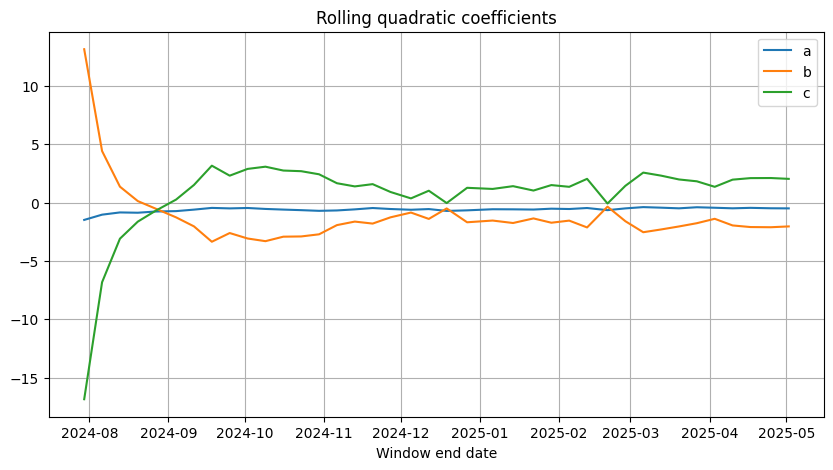

In [209]:
def plot_coefficients(coeffs):
    plt.figure(figsize=(10, 5))
    plt.plot(coeffs["window_end"], coeffs["a"], label="a")
    plt.plot(coeffs["window_end"], coeffs["b"], label="b")
    plt.plot(coeffs["window_end"], coeffs["c"], label="c")
    plt.legend()
    plt.title("Rolling quadratic coefficients")
    plt.xlabel("Window end date")
    plt.grid(True)
    plt.show()

plot_coefficients(coeffs)

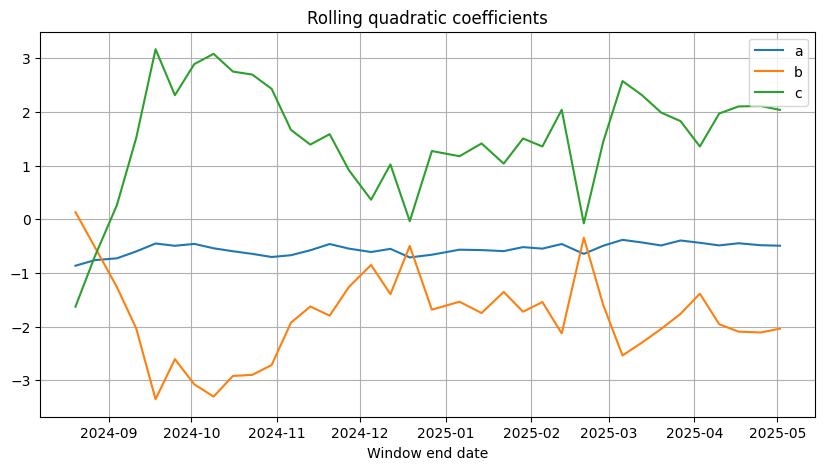

In [211]:
burn_in_windows = 3   
coeffs_report = coeffs.iloc[burn_in_windows:].copy()
plot_coefficients(coeffs_report)

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


def estimate_rolling_quadratic_both_versions(
    panel,
    window_size=63,
    step_size=5,
    min_obs=500,
    min_abs_return=0.0015,
    trim_quantiles=(0.01, 0.99)
):
   

    df = panel.copy().sort_values(["date", "option_id"]).reset_index(drop=True)
    unique_dates = np.array(sorted(df["date"].dropna().unique()))

    results = []

    for start in range(0, len(unique_dates) - window_size + 1, step_size):
        train_dates = unique_dates[start:start + window_size]
        window_end = train_dates[-1]

        w = df[df["date"].isin(train_dates)].copy()

        w = w.dropna(subset=[
            "dV", "dS",
            "delta_bs_lag", "vega_bs_lag",
            "tau_lag", "S_lag"
        ])

        w = w[w["tau_lag"] > 14/252]
        w = w[(w["delta_bs_lag"] <= 0.95) & (w["delta_bs_lag"] >= 0.05) ]
       
        w = w[w["vega_bs_lag"] > 1e-8]
        w = w[w["S_lag"] > 0]
        w = w[(w["dS"].abs() / w["S_lag"]) > min_abs_return]

        if len(w) < min_obs:
            results.append({
                "window_end": window_end,
                "n_obs": len(w),
                "delta_mean": np.nan,

                "a_raw": np.nan, "b_raw": np.nan, "c_raw": np.nan, "r2_raw": np.nan,
                "alpha_ctr": np.nan, "beta_ctr": np.nan, "gamma_ctr": np.nan, "r2_ctr": np.nan,
                "a_from_centered": np.nan, "b_from_centered": np.nan, "c_from_centered": np.nan
            })
            continue

        y = (
            (w["dV"] - w["delta_bs_lag"] * w["dS"])
            * w["S_lag"] * np.sqrt(w["tau_lag"])
            / (w["vega_bs_lag"] * w["dS"])
        )

        x = w["delta_bs_lag"]

        # trim y outliers
        q_low, q_high = y.quantile(trim_quantiles)
        mask = (y >= q_low) & (y <= q_high) & np.isfinite(y) & np.isfinite(x)

        y_reg = y.loc[mask]
        x_reg = x.loc[mask]

        if len(y_reg) < min_obs:
            results.append({
                "window_end": window_end,
                "n_obs": len(y_reg),
                "delta_mean": np.nan,

                "a_raw": np.nan, "b_raw": np.nan, "c_raw": np.nan, "r2_raw": np.nan,
                "alpha_ctr": np.nan, "beta_ctr": np.nan, "gamma_ctr": np.nan, "r2_ctr": np.nan,
                "a_from_centered": np.nan, "b_from_centered": np.nan, "c_from_centered": np.nan
            })
            continue

        # ---------- raw basis ----------
        X_raw = pd.DataFrame({
            "const": 1.0,
            "delta": x_reg,
            "delta_sq": x_reg**2
        })
        model_raw = sm.OLS(y_reg, X_raw).fit()

        a_raw = model_raw.params["const"]
        b_raw = model_raw.params["delta"]
        c_raw = model_raw.params["delta_sq"]

        # ---------- centered basis ----------
        mu = x_reg.mean()
        z = x_reg - mu

        X_ctr = pd.DataFrame({
            "const": 1.0,
            "z": z,
            "z_sq": z**2
        })
        model_ctr = sm.OLS(y_reg, X_ctr).fit()

        alpha = model_ctr.params["const"]
        beta = model_ctr.params["z"]
        gamma = model_ctr.params["z_sq"]

       
        a_from_centered = alpha - beta * mu + gamma * mu**2
        b_from_centered = beta - 2 * gamma * mu
        c_from_centered = gamma

        results.append({
            "window_end": window_end,
            "n_obs": len(y_reg),
            "delta_mean": mu,

            "a_raw": a_raw,
            "b_raw": b_raw,
            "c_raw": c_raw,
            "r2_raw": model_raw.rsquared,

            "alpha_ctr": alpha,
            "beta_ctr": beta,
            "gamma_ctr": gamma,
            "r2_ctr": model_ctr.rsquared,

            "a_from_centered": a_from_centered,
            "b_from_centered": b_from_centered,
            "c_from_centered": c_from_centered
        })

    return pd.DataFrame(results)


    Estimate rolling quadratic coefficients in two forms:

    1 Raw basis:
       y = a + b*delta + c*delta^2 + eps

    2 Centered basis:
       y = alpha + beta*z + gamma*z^2 + eps,
       where z = delta - mean(delta in the window)

    Then convert the centered-basis coefficients back into the
    raw basis so both versions can be compared on the same footing.


Convert centered-basis coefficients back to raw basis:
         alpha + beta*(x-mu) + gamma*(x-mu)^2
         = [alpha - beta*mu + gamma*mu^2] + [beta - 2*gamma*mu]x + gamma*x^2

In [233]:
def plot_raw_vs_centered_coefficients(coeffs_both):
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    
    axes[0].plot(coeffs_both["window_end"], coeffs_both["a_raw"], label="a_raw")
    axes[0].plot(coeffs_both["window_end"], coeffs_both["b_raw"], label="b_raw")
    axes[0].plot(coeffs_both["window_end"], coeffs_both["c_raw"], label="c_raw")
    axes[0].set_title("Raw-basis coefficients")
    axes[0].legend()
    axes[0].grid(True)

    
    axes[1].plot(coeffs_both["window_end"], coeffs_both["alpha_ctr"], label="alpha_ctr")
    axes[1].plot(coeffs_both["window_end"], coeffs_both["beta_ctr"], label="beta_ctr")
    axes[1].plot(coeffs_both["window_end"], coeffs_both["gamma_ctr"], label="gamma_ctr")
    axes[1].set_title("Centered-basis coefficients")
    axes[1].legend()
    axes[1].grid(True)

   
    axes[2].plot(coeffs_both["window_end"], coeffs_both["a_from_centered"], label="a_from_centered")
    axes[2].plot(coeffs_both["window_end"], coeffs_both["b_from_centered"], label="b_from_centered")
    axes[2].plot(coeffs_both["window_end"], coeffs_both["c_from_centered"], label="c_from_centered")
    axes[2].set_title("Centered regression converted back to raw basis")
    axes[2].legend()
    axes[2].grid(True)

    plt.xlabel("Window end date")
    plt.tight_layout()
    plt.show()

In [ ]:

def plot_fitted_correction_curves_side_by_side(
    coeffs_both,
    selected_dates=None,
    n_dates=6,
    delta_min=0.05,
    delta_max=0.95
):
    
    cdf = coeffs_both.dropna(subset=["a_raw", "b_raw", "c_raw"]).copy()
    if cdf.empty:
        print("No valid coefficient rows to plot.")
        return

    if selected_dates is None:
        idx = np.linspace(0, len(cdf) - 1, min(n_dates, len(cdf))).astype(int)
        selected = cdf.iloc[idx].copy()
    else:
        selected = cdf[cdf["window_end"].isin(pd.to_datetime(selected_dates))].copy()

    delta_grid = np.linspace(delta_min, delta_max, 200)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for _, row in selected.iterrows():
        label = str(pd.to_datetime(row["window_end"]).date())

        g_raw = row["a_raw"] + row["b_raw"] * delta_grid + row["c_raw"] * delta_grid**2
        g_ctr = (
            row["a_from_centered"]
            + row["b_from_centered"] * delta_grid
            + row["c_from_centered"] * delta_grid**2
        )

        axes[0].plot(delta_grid, g_raw, label=label)
        axes[1].plot(delta_grid, g_ctr, label=label)

    axes[0].axhline(0.0, linestyle="--")
    axes[1].axhline(0.0, linestyle="--")

    axes[0].set_title("Fitted correction curve: raw-basis regression")
    axes[1].set_title("Fitted correction curve: centered-delta regression")

    for ax in axes:
        ax.set_xlabel("Delta")
        ax.set_ylabel("g(delta) = a + b·delta + c·delta²")
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()



   Side-by-side plot:
    left  = fitted correction from raw-basis regression
    right = fitted correction from centered-basis regression,
            converted back to raw basis


In [244]:
def compute_empirical_bucket_correction(panel):
    df = panel.copy()

    
    df = df.dropna(subset=["dV", "dS", "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag"]).copy()
    df = df[df["tau_lag"] > 14/252]
    df = df[df["vega_bs_lag"] > 1e-8]
    df = df[(df["delta_bs_lag"] <= 0.95) & (df["delta_bs_lag"] >= 0.05) ]
    df = df[(df["dS"].abs() / df["S_lag"]) > 0.0015]

    df["y_hw"] = (
        (df["dV"] - df["delta_bs_lag"] * df["dS"])
        * df["S_lag"] * np.sqrt(df["tau_lag"])
        / (df["vega_bs_lag"] * df["dS"])
    )

   
    edges = np.append(np.arange(0.05, 0.95 + 0.10, 0.10), 1.05)
    labels = [f"[{edges[i]:.2f},{edges[i+1]:.2f})" for i in range(len(edges)-1)]

    df["delta_bucket_lag"] = pd.cut(
        df["delta_bs_lag"],
        bins=edges,
        labels=labels,
        right=False,
        include_lowest=True
    )

    out = (
        df.groupby("delta_bucket_lag", observed=False)
          .agg(
              n_obs=("y_hw", "size"),
              mean_delta=("delta_bs_lag", "mean"),
              mean_y=("y_hw", "mean")
          )
          .reset_index()
    )
    return out

In [246]:
def plot_curve_vs_bucket_averages(coeffs_both, bucket_avg, which_date=None, use_centered=True):
    cdf = coeffs_both.dropna(subset=["a_raw", "b_raw", "c_raw"]).copy()
    if cdf.empty:
        print("No valid coefficient rows.")
        return

    if which_date is None:
        row = cdf.iloc[-1]   # use latest valid window
    else:
        row = cdf.loc[cdf["window_end"] == pd.to_datetime(which_date)].iloc[0]

    delta_grid = np.linspace(0.05, 0.95, 200)

    if use_centered:
        g = (
            row["a_from_centered"]
            + row["b_from_centered"] * delta_grid
            + row["c_from_centered"] * delta_grid**2
        )
        title_suffix = "centered-delta regression"
    else:
        g = row["a_raw"] + row["b_raw"] * delta_grid + row["c_raw"] * delta_grid**2
        title_suffix = "raw-basis regression"

    plt.figure(figsize=(8, 5))
    plt.plot(delta_grid, g, label="Fitted correction curve")
    plt.scatter(bucket_avg["mean_delta"], bucket_avg["mean_y"], s=60, label="Empirical bucket averages")

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Delta")
    plt.ylabel("Correction target")
    plt.title(f"Fitted correction vs empirical bucket averages ({title_suffix})")
    plt.grid(True)
    plt.legend()
    plt.show()

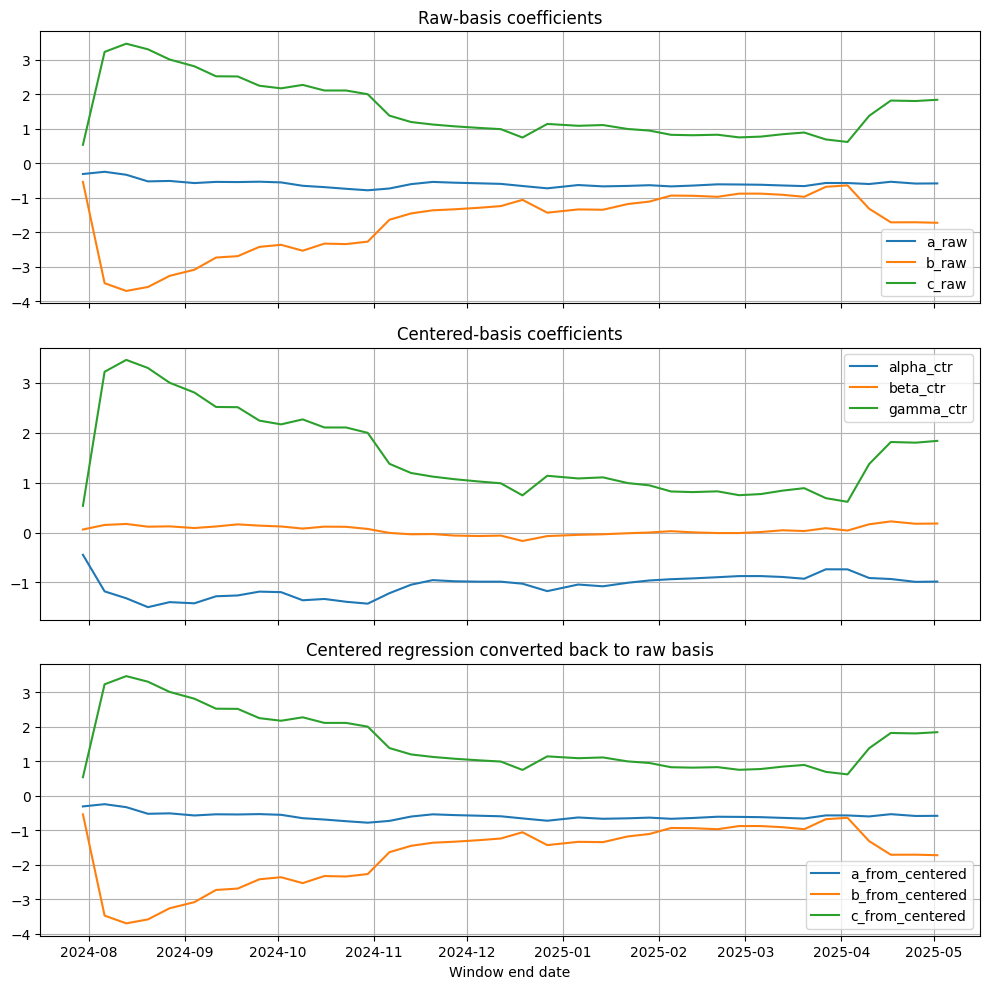

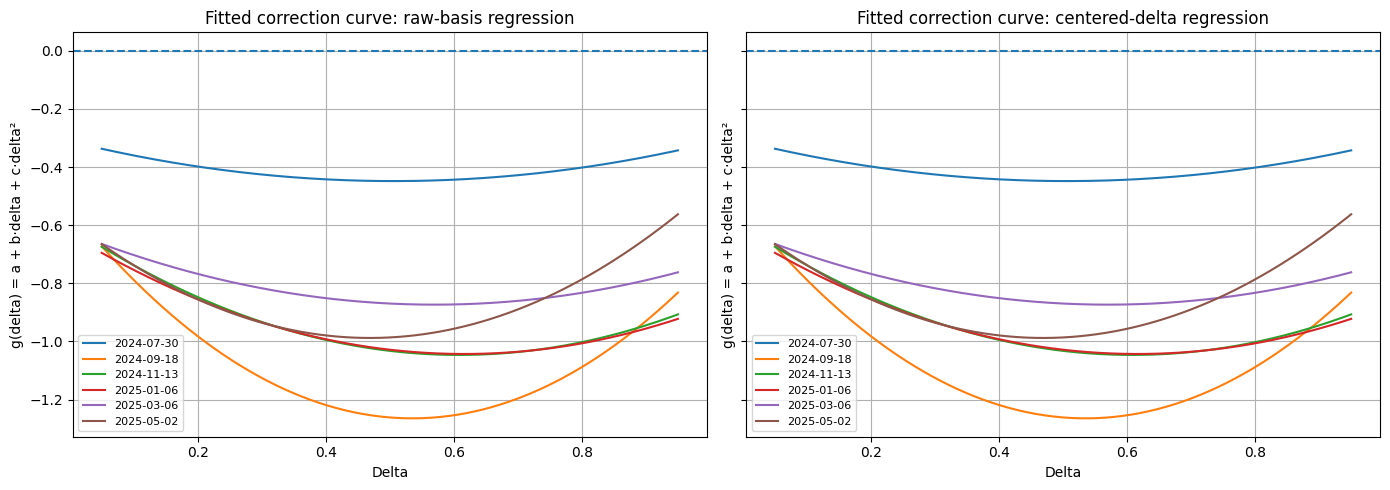

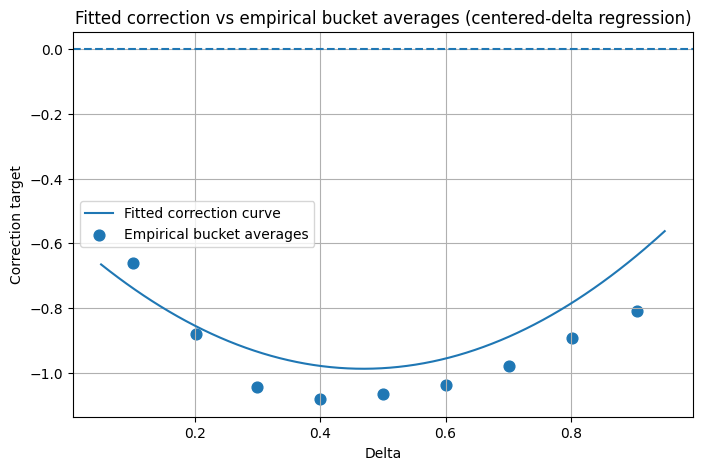

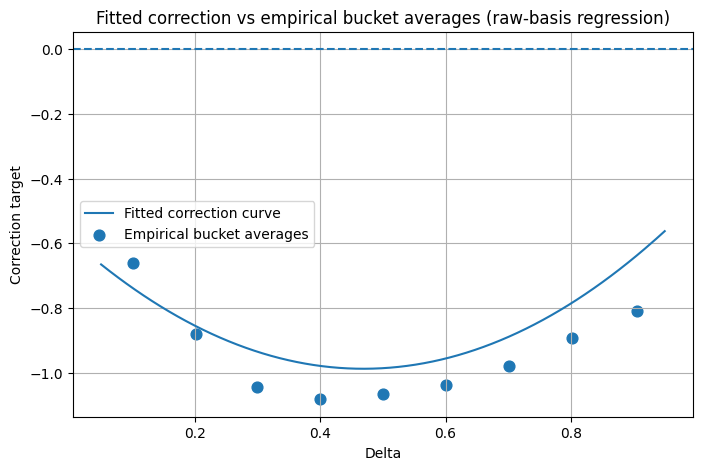

In [248]:
# Step A: estimate both versions
coeffs_both = estimate_rolling_quadratic_both_versions(
    panel,
    window_size=63,
    step_size=5,
    min_obs=500,
    min_abs_return=0.0015,
    trim_quantiles=(0.01, 0.99)
)

# Step B: compare coefficient paths
plot_raw_vs_centered_coefficients(coeffs_both)

# Step C: compare fitted correction curves
plot_fitted_correction_curves_side_by_side(coeffs_both, n_dates=6)

# Step D: compute empirical bucket averages
bucket_avg = compute_empirical_bucket_correction(panel)

# Step E: compare latest fitted curve with bucket averages
plot_curve_vs_bucket_averages(coeffs_both, bucket_avg, use_centered=True)
plot_curve_vs_bucket_averages(coeffs_both, bucket_avg, use_centered=False)